In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df= pd.read_csv("Titanic copy.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [21]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [22]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [73]:
#categorical columns
cat_col1=[col for col in df.columns if df[col].dtype=="object"]
print("Categorical data",cat_col1)

#numerical columns
num_col1=[col for col in df.columns if df[col].dtype!="object"]
print("Numerical data : ",num_col1)

Categorical data ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical data :  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [72]:
#categorical columns
cat_col=df.select_dtypes(include='object').columns
num_col=df.select_dtypes(include='number').columns

print("categorical columns : ",cat_col.tolist())

print("Numerical columns : ",num_col.tolist())

categorical columns :  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns :  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [26]:
df.shape

(891, 12)

In [27]:
round((df.isnull().sum()/df.shape[0])*100,2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [28]:
df.isnull().sum().sum()

np.int64(866)

In [29]:
df.notnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,True,True,True,True,True,True,True,True,True,True,False,True
1,True,True,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True,False,True
3,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,True,True,True,True,True,True,True,True,True,True,False,True
887,True,True,True,True,True,True,True,True,True,True,True,True
888,True,True,True,True,True,False,True,True,True,True,False,True
889,True,True,True,True,True,True,True,True,True,True,True,True


In [30]:
df.notnull().sum().sum()

np.int64(9826)

In [31]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [32]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [35]:
df_clean=df.drop(columns=['Name','Ticket','Cabin'])
df_clean

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [36]:
df_dropna_rows=df.dropna()

In [37]:
df_dropna_rows.shape

(183, 12)

In [38]:
df_dropna_cols=df.dropna(axis=1)
df_dropna_cols.shape

(891, 9)

In [40]:
from sklearn.impute import SimpleImputer
df_mean_impute=df.copy()
mean_imputer=SimpleImputer(strategy='mean')
df_mean_impute['Age']=mean_imputer.fit_transform(df_mean_impute[['Age']])

df_mean_impute['Age'].isnull().sum()

np.int64(0)

In [50]:
df_impute = df.copy()

mode_imputer = SimpleImputer(strategy='most_frequent')

df_impute['Embarked'] = mode_imputer.fit_transform(df_impute[['Embarked']]).ravel()

df_impute['Embarked'].isnull().sum()
# df_impute

np.int64(0)

#### Forward Fill

In [63]:
df_ffill = df.copy()

#df_ffill['Age'] = df_ffill['Age'].fillna(method='ffill')


df_ffill = df_ffill.ffill()

print(df_ffill.isnull().sum())
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          1
Embarked       0
dtype: int64
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


#### Backward fill

In [64]:
df_bfill=df.copy()
df_bfill=df_bfill.bfill()

df_bfill.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          1
Embarked       0
dtype: int64

In [67]:
df_custom=df.copy()
df_custom['Cabin']=df_custom['Cabin'].fillna('Unknown')
df_custom['Cabin'].isnull().sum()

np.int64(0)

#### Plot Histogram

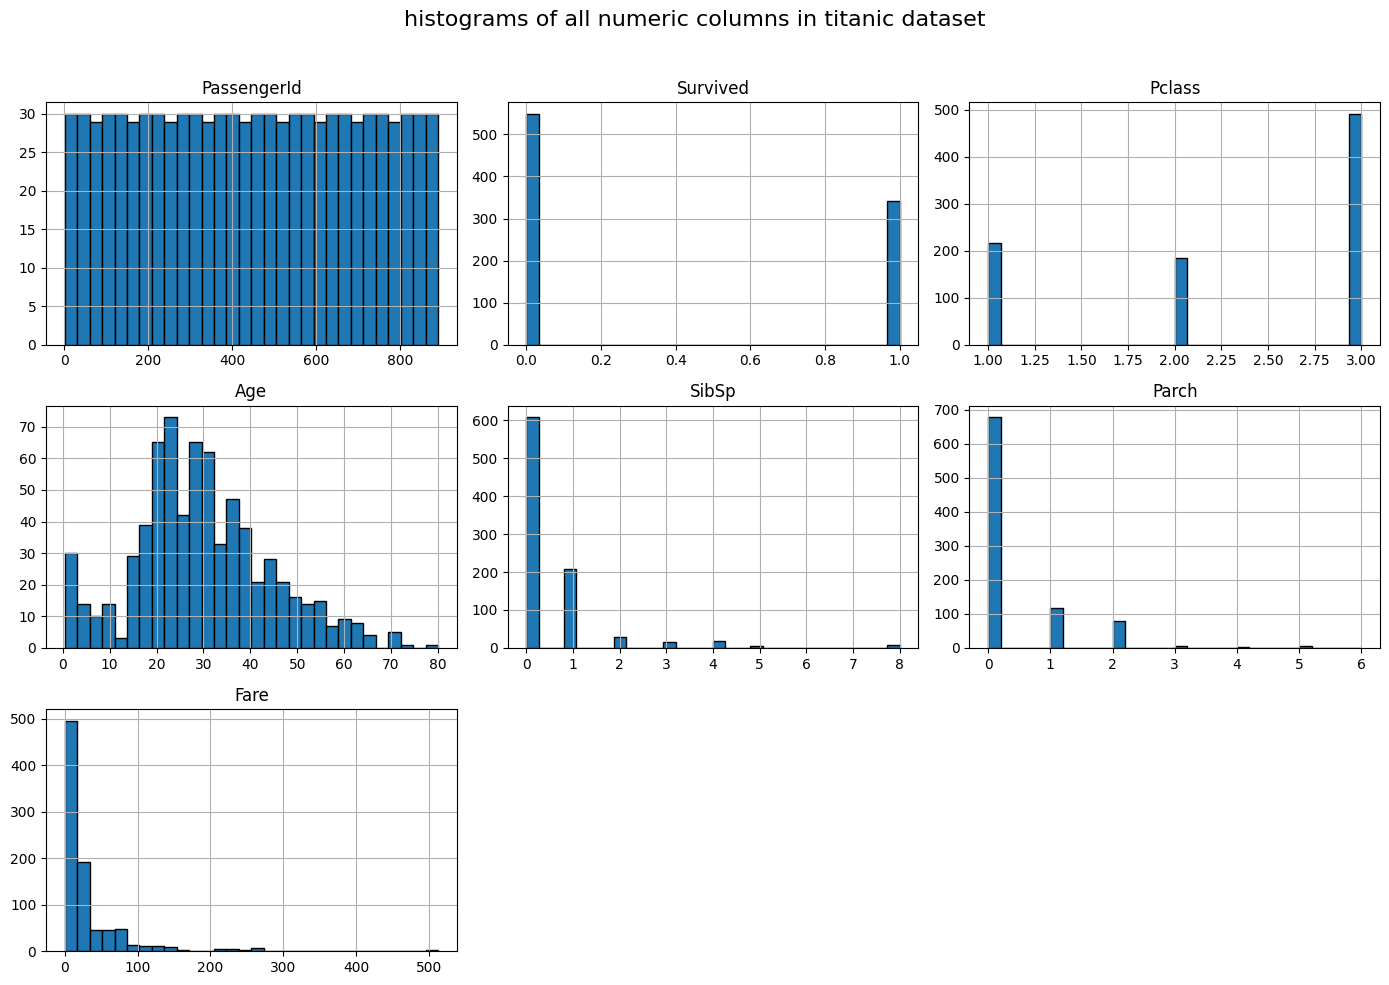

In [76]:
cat_col=df.select_dtypes(include='object').columns
num_col=df.select_dtypes(include='number')
num_col.hist(bins=30, figsize=(14,10),edgecolor='black')
plt.suptitle("histograms of all numeric columns in titanic dataset",fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [77]:
df_melted=pd.melt(num_col)
df_melted

,variable,value
0,PassengerId,1.00
1,PassengerId,2.00
2,PassengerId,3.00
3,PassengerId,4.00
4,PassengerId,5.00
...,...,...
6232,Fare,13.00
6233,Fare,30.00
6234,Fare,23.45
6235,Fare,30.00


In [78]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

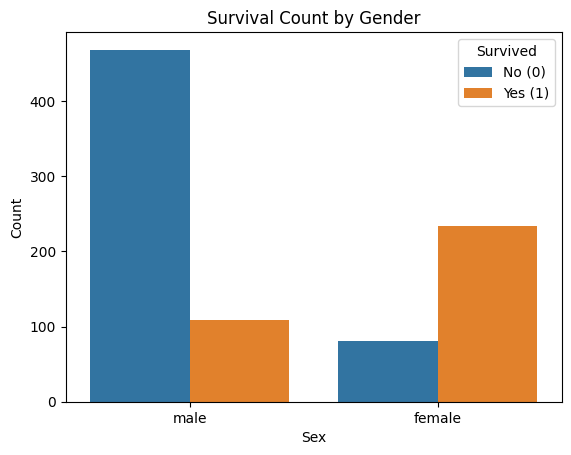

In [79]:
#plot the survival count
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No (0)', 'Yes (1)'])
plt.show()

Text(0.5, 1.0, 'Gender Distribution')

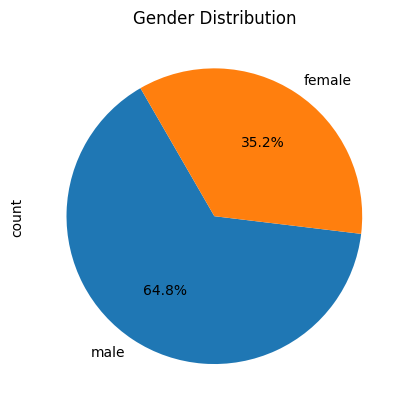

In [80]:
df['Sex'].value_counts().plot.pie(autopct='%1.1f%%',startangle=120)
plt.title('Gender Distribution')

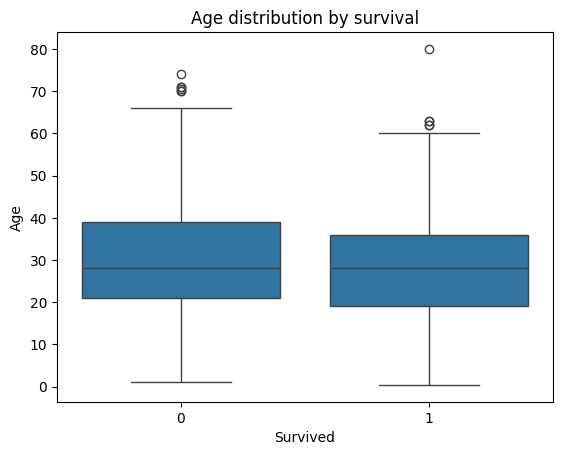

In [82]:
sns.boxplot(x='Survived',y='Age' ,data=df)
plt.title("Age distribution by survival")
plt.show()

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


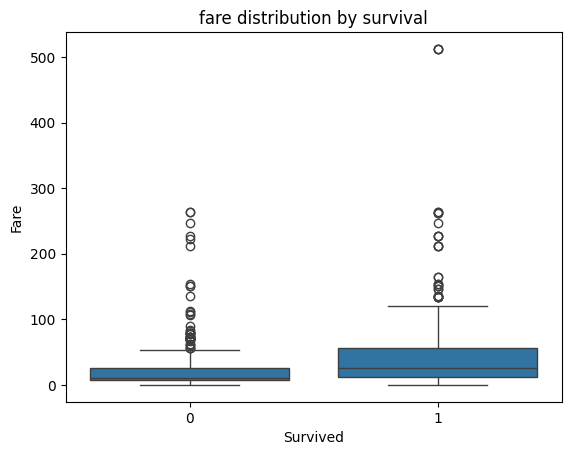

In [84]:
sns.boxplot(x='Survived',y='Fare' ,data=df)
plt.title("fare distribution by survival")
plt.show()

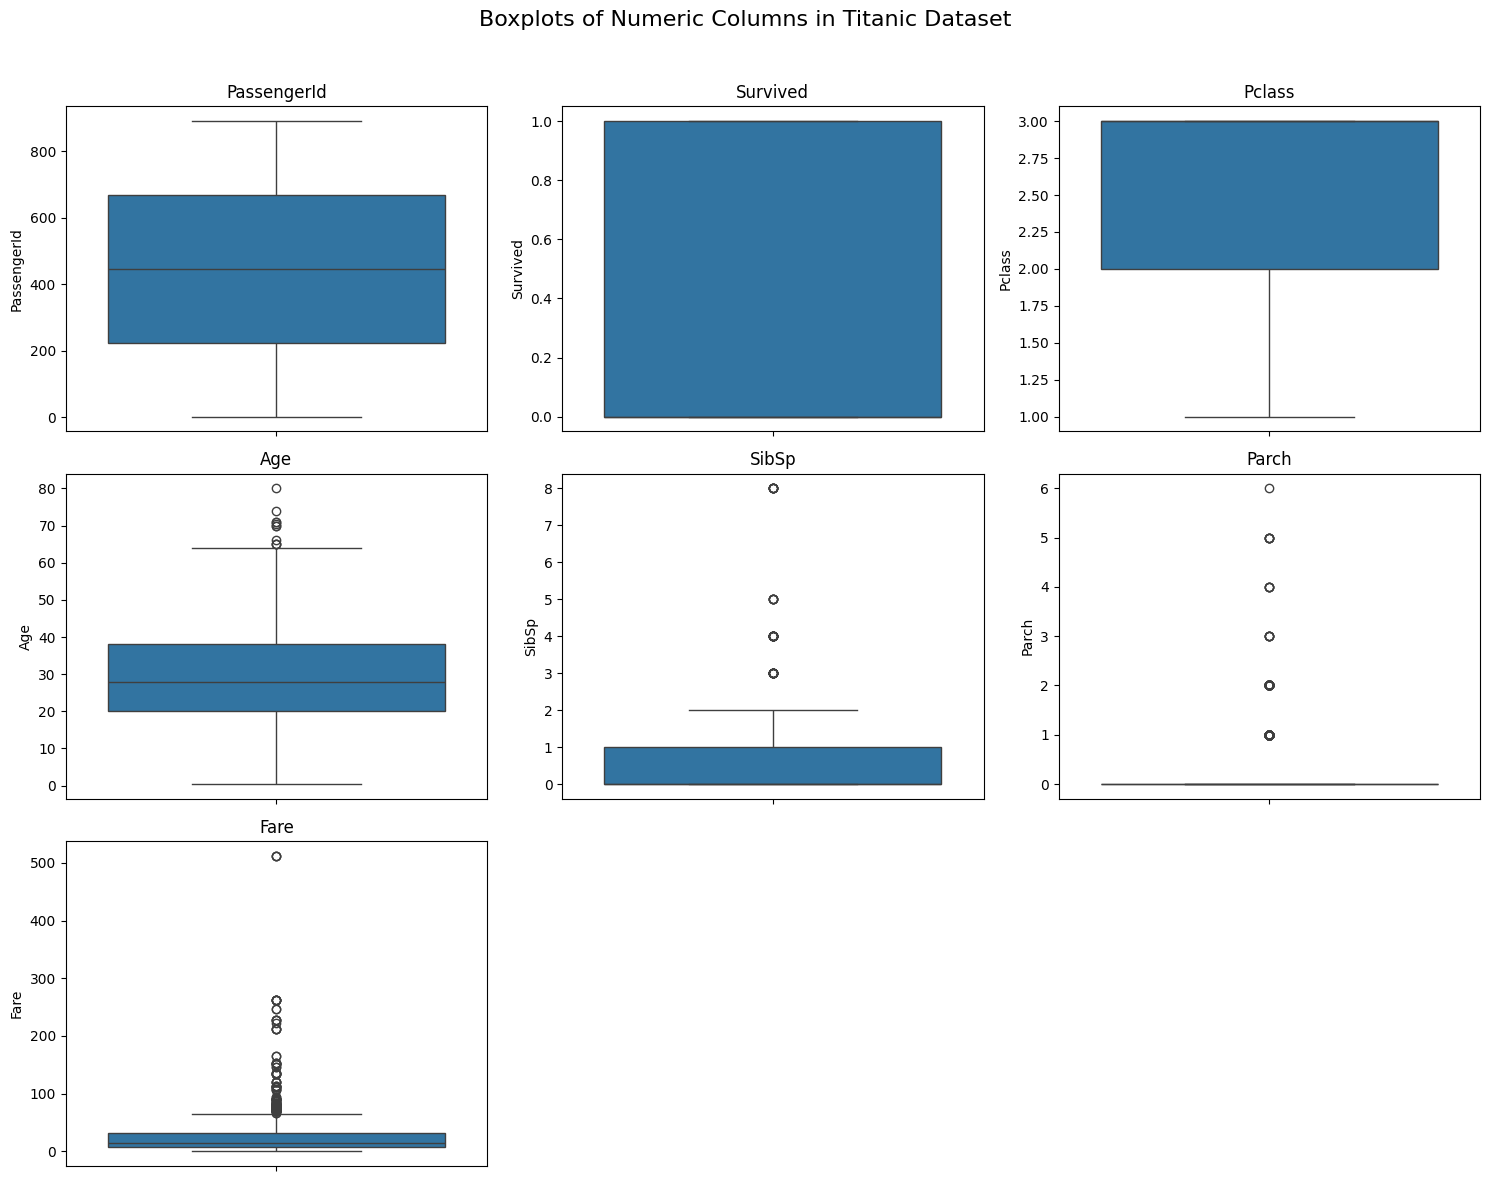

In [85]:
num_col = df.select_dtypes(include=['number'])

# Create subplots
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15,12)
)

axes = axes.flatten()

# Plot boxplot for each numeric column
for i, col in enumerate(num_col.columns):
    sns.boxplot(
        y=num_col[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

# Remove empty subplot if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Boxplots of Numeric Columns in Titanic Dataset",
    fontsize=16
)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()